In [2]:
from utils.binaries import *
from utils.plotting import *
from matplotlib.patches import Rectangle

set_plt_style("double tex")

16:12:38 (  +42.2s) [INFO   ] -- import logging
16:12:38 (  +229ms) [INFO   ] -- import numpy as np
16:12:39 (   +12ms) [INFO   ] -- import uncertainties
16:12:39 (  +560ms) [INFO   ] -- import pandas as pd
16:12:39 (    +0ms) [WARNING] -- pandas support to be dropped at some point!
16:12:39 (    +4ms) [INFO   ] -- import binaries.tools as tools
16:12:39 (    +3ms) [INFO   ] -- set MONI_PATH = PosixPath('/cr/work/filip/monit_and_sd')
16:12:39 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/cr/work/filip/monit_and_sd')
16:12:39 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/cr/data01/filip/plots')
16:12:39 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/cr/data01/filip/Data')
16:12:39 (    +1ms) [INFO   ] -- set SCAN_PATH = PosixPath('/cr/data01/filip/xy-calibration')
16:12:39 (    +0ms) [INFO   ] -- set OFLN_PATH = PosixPath('/cr/data01/filip/offline/install')
16:12:40 (  +519ms) [INFO   ] -- import matplotlib.pyplot as plt
16:12:40 (  +892ms) [INFO   ] -- import seaborn a

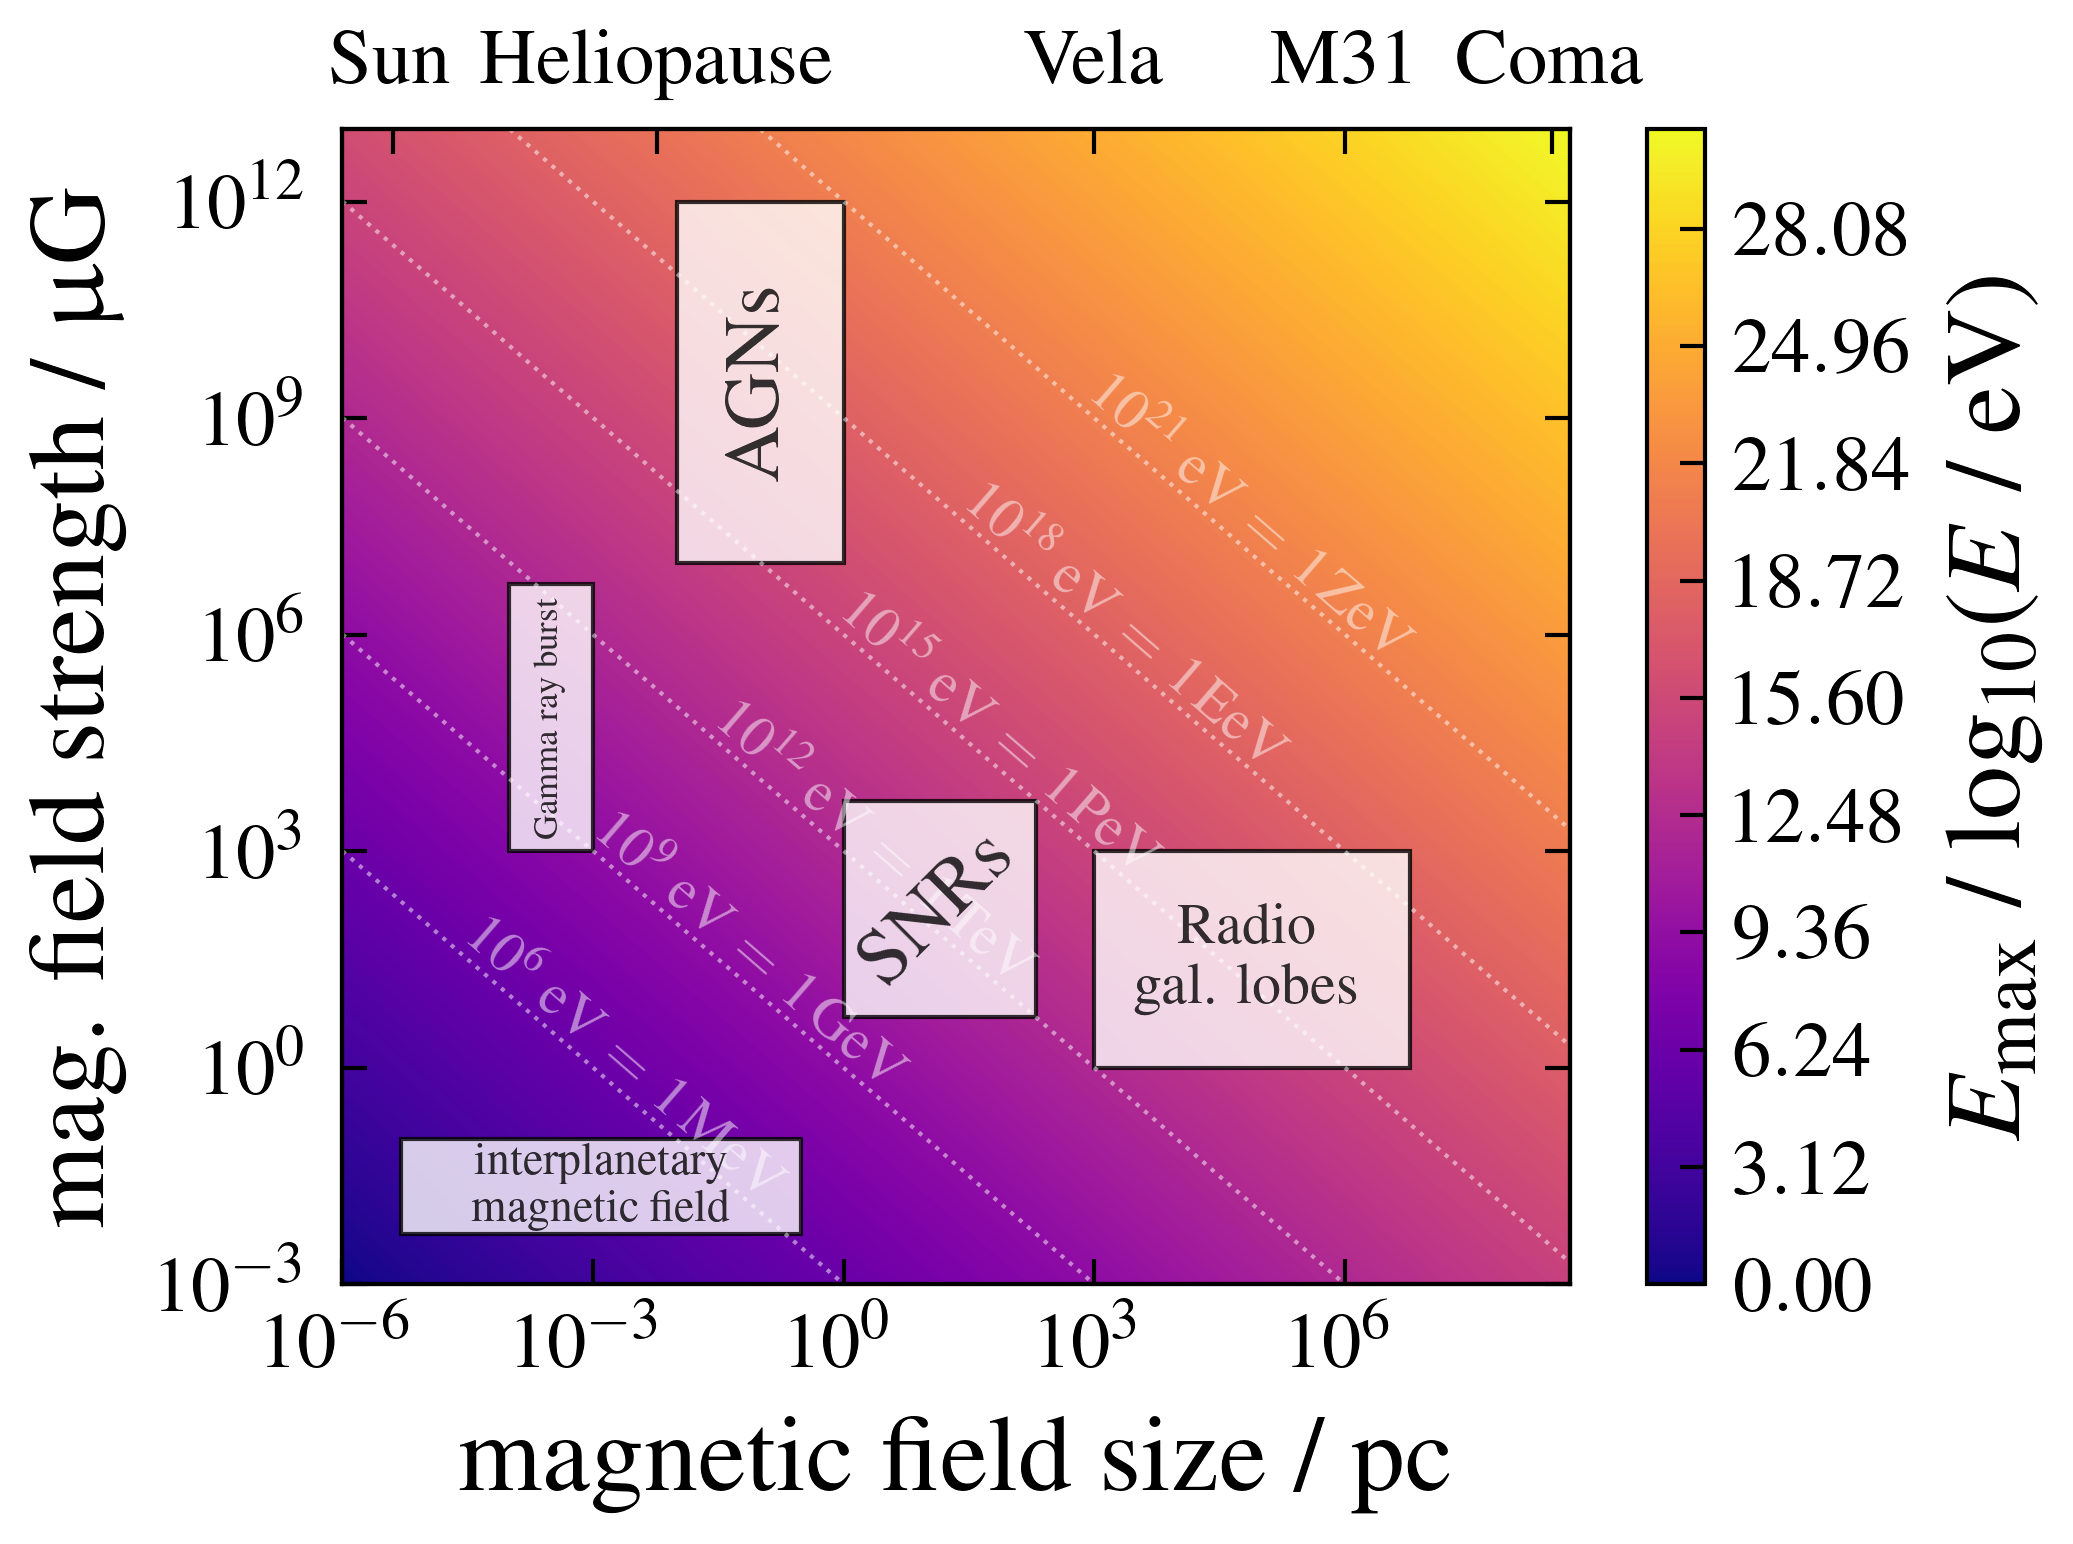

In [53]:
def fmt(tick):
    match tick:
        case  6: return r"$10^{ 6}\,\,\mathrm{eV}\,=\,1\,\mathrm{MeV}$"
        case  9: return r"$10^{ 9}\,\,\mathrm{eV}\,=\,1\,\mathrm{GeV}$"
        case 12: return r"$10^{12}\,\,\mathrm{eV}\,=\,1\,\mathrm{TeV}$"
        case 15: return r"$10^{15}\,\,\mathrm{eV}\,=\,1\,\mathrm{PeV}$"
        case 18: return r"$10^{18}\,\,\mathrm{eV}\,=\,1\,\mathrm{EeV}$"
        case 21: return r"$10^{21}\,\,\mathrm{eV}\,=\,1\,\mathrm{ZeV}$"
        case 24: return r"$10^{24}\,\,\mathrm{eV}$" #\,=\,1\,\mathrm{YeV}$"

        case _ : return ""

def get_center(rectangle):

    # geometric mean gives the middle on a log scale (i think)
    x, y = rectangle.get_xy()
    dx = rectangle.get_width()
    dy = rectangle.get_height()

    return np.array([np.sqrt(x*dx), np.sqrt(y*dy)])

x_min, x_max = 1e-6, 5e8
y_min, y_max = 1e-3, 1e13

ax = plt.gca()
ax.set_xscale("log") 
ax.set_yscale("log")
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel("magnetic field size / $\mathrm{pc}$")
ax.set_ylabel(r"mag. field strength / $\upmu\mathrm{G}$")

q, beta = 1, 0.5
field_size = x = np.geomspace(x_min, x_max, 100)
field_strength = y = np.geomspace(y_min, y_max, 100)

xx, yy = np.meshgrid(x, y)
z = np.log10(0.5 * (xx * yy) * q / beta) + 9

contour = ax.contourf(x, y, z, levels = 500, cmap = "plasma", zorder = 0)
bar = plt.colorbar(contour, ax = ax)
bar.set_label("$E_\mathrm{max}$ / log$_{10}$($E$ / $\mathrm{eV}$)")

# # context
CS = plt.contour(xx, yy, z, levels=range(6, 24, 3), colors='w', 
                 alpha=0.5, linestyles=':', linewidths=0.5)

for i in range(6, 30, 3):
    plt.text(0.08 * 10 ** ((i-15)/2), 
             35 * 10 ** ((i-15)/2), 
             fmt(i-6), 
             ha='center', va='center', 
             rotation=-41, fontsize=7, 
             c='w', alpha=0.5)

ax_x = plt.gca().twiny()
ax_x.set_xscale("log")
ax_x.set_xlim(x_min, x_max)
_ = ax_x.set_xticks([4e-6, 0.586625e-2, 1e3, 1e6, 3e8], ["Sun", "Heliopause", "Vela", "M31", "Coma"])

# plt.gca().clabel(CS, CS.levels, fmt=fmt, fontsize=10, inline=True, inline_spacing=-109)

SNRs = ax.add_patch(Rectangle((1, 5), 199, 4995, fc = "w", color = "k", lw=0.5, alpha=0.8))         # Supernova Remnants
_ = ax.annotate("SNRs", get_center(SNRs) , ha='center', va='center', alpha=0.8, rotation=45)
AGNs = ax.add_patch(Rectangle((1e-2, 1e7), 0.99, 1e12, fc = "w", color = "k", lw=0.5, alpha=0.8))   # Active galactic nuclei
_ = ax.annotate("AGNs", get_center(AGNs) + np.array([3e-6, 0]) , ha='center', va='center', alpha=0.8, rotation=90)
RGs = ax.add_patch(Rectangle((1e3, 1), 5.999e6, 0.999e3, fc = "w", color = "k", lw=0.5, alpha=0.8)) # Radio Galaxies
_ = ax.annotate("Radio\ngal. lobes", get_center(RGs) - np.array([1e4, 0]), ha='center', va='center', alpha=0.8, fontsize=7)
IMF = ax.add_patch(Rectangle((5e-6, 5e-3), 0.3066, 1e-1, fc = "w", color = "k", lw=0.5, alpha=0.8)) # Interplanetary Magnetic Field
_ = ax.annotate("interplanetary\nmagnetic field", get_center(IMF), ha='center', va='center', alpha=0.8, fontsize=5.5)
GRB = ax.add_patch(Rectangle((1e-4, 1e3), 0.9e-3, 4.999e6, fc = "w", color = "k", lw=0.5, alpha=0.8)) # Interplanetary Magnetic Field
_ = ax.annotate("Gamma ray burst", get_center(GRB), ha='center', va='center', alpha=0.8, fontsize=4.2, rotation=90)

# plt.scatter( 8.594, 8.3e4, s = 50, fc = "w", edgecolor = "k")                   # LHC
# plt.gca().add_patch(Rectangle((8, 1e9-5), 10, 1e14, fc = "w", color = "k"))     # Pulsars
# plt.gca().add_patch(Rectangle((3e18, 1e-5), 1e20, 1e-3, fc = "w", color = "k")) # RGs
# plt.gca().add_patch(Rectangle((6e3, 8.2e4), 1e4, 1e9, fc = "w", color = "k"))   # White dwarf
# plt.scatter( 1e3, 1e3, s = 800, fc = "w", edgecolor = "k")                      # Sunspots

# plt.text(13, 2e5, "LHC", c = "w", weight = "bold")
# plt.text(4e3, 1e2, "Sunspots", c = "w", weight = "bold")
# plt.text(30, 1e12, "Pulsars", c = "w", weight = "bold")
# plt.text(1.5e18, 5e-3, "  Radio\nGalaxies", c = "w", weight = "bold")
# plt.text(2e4, 2e5, "White\nDwarfs", c = "w", weight = "bold")

# plt.plot([10, 1e22], [1e15, 1e-6], c = "k", ls = "--")                          # GZK
# plt.text(1e4, 1.5e7, r"GZK-Cutoff $\approx 10^{20}\;\mathrm{eV}$", rotation = -34, c = "k")
# plt.plot([1, 1e19], [1e13, 1e-6], c = "k", ls = "--")                           # Proton knee
# plt.text(1e4, 1e4, r"Proton knee $\approx 10^{16}\;\mathrm{eV}$", rotation = -34, c = "k")
# plt.plot([1.0,1e6], [1.0, 1e-6], c = "lightgray", ls = "--")                    # Aurora
# plt.text(3, 1e-6, r"Aurora Borealis $\approx 10^{3}\;\mathrm{eV}$", rotation = -34, c = "lightgray")
# plt.plot([1e6, 1e23], [1e15, 1e-2], c = "whitesmoke", ls = "--")
# plt.text(1e17, 2.7e-1, r"GUT-Scale $\approx 10^{25}\,\mathrm{eV}$", rotation = -34, c = "whitesmoke")

plot.save(plt.gcf(), "hillas_plot")